# code for event segmentation procedure

Adapted from https://github.com/ContextLab/sherlock-topic-model-paper/blob/master/code/notebooks/main/eventseg_analysis.ipynb

### imports

In [1]:
import numpy as np
import pandas as pd
import hypertools as hyp
import brainiak.eventseg.event as event
import pickle
import os
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### functions

In [128]:
def reduce_model(m, ev):
    """
    Reduce a model based on event labels
    """
    w = (np.round(ev.segments_[0])==1).astype(bool)
    return np.array([m[wi, :].mean(0) for wi in w.T])

### paths

In [232]:
data_dir = '../../data'
ep_data_dir = f'{data_dir}/models/episodes'
rec_data_dir = f'{data_dir}/models/recalls'
ep_traj_dir = f'{ep_data_dir}/trajectories'
ep_events_dir = f'{ep_data_dir}/events'
ep_eventseg_dir = f'{ep_data_dir}/eventseg-models'
ep_eventtimes_dir = f'{ep_data_dir}/event-times'
ep_emb_dir = f'{ep_data_dir}/embeddings'
rec_traj_dir = f'{rec_data_dir}/trajectories'
rec_events_dir = f'{rec_data_dir}/events'
rec_eventseg_dir = f'{rec_data_dir}/eventseg-models'
rec_eventtimes_dir = f'{rec_data_dir}/event-times'
rec_emb_dir = f'{rec_data_dir}/embeddings'
pickle_dir = '../../data/pickles'

## load episode trajectories

In [304]:
episode_trajs = {ep: np.load(f'{ep_traj_dir}/{ep}_trajectory.npy') for ep in ['atlep1', 'atlep2', 'arrdev']}

## load recall trajectories

In [233]:
recall_trajs = {rectype : [] for rectype in ['atlep1', 'prediction', 'delayed', 'atlep2', 'arrdev']}
avg_recall_trajs = dict.fromkeys(recall_trajs)

for rectype in recall_trajs.keys():
    rt_dir = os.path.join(rec_traj_dir, rectype)
    for f in os.listdir(rt_dir):
        if f.startswith('debug'):
            recall_trajs[rectype].append((f.replace('.npy',''), np.load(os.path.join(rt_dir, f))))
        elif f.startswith('avg_trajectory'):
            avg_recall_trajs[rectype] = np.load(os.path.join(rt_dir, f))

## find optimal k for each episode trajectory

In [5]:
ep_ks = {ep : [] for ep in episode_trajs.keys()}

for ep in ep_ks.keys():
    corrmat = np.corrcoef(episode_trajs[ep])
    print(ep)
    for n_events in range(2, 51):
        print(f'\tfitting to {n_events} events...')
        ev = event.EventSegment(n_events)
        ev.fit(episode_trajs[ep])
        roundedmat = np.round(ev.segments_[0]).astype(int)
        mask = np.sum(list(map(lambda x: np.outer(x, x), roundedmat.T)), 0).astype(bool)
        within = corrmat[mask].mean()
        across = corrmat[~mask].mean()
        ep_ks[ep].append((within, across, within/across))

atlep1
	fitting to 2 events...
	fitting to 3 events...
	fitting to 4 events...
	fitting to 5 events...
	fitting to 6 events...
	fitting to 7 events...
	fitting to 8 events...
	fitting to 9 events...
	fitting to 10 events...
	fitting to 11 events...
	fitting to 12 events...
	fitting to 13 events...
	fitting to 14 events...
	fitting to 15 events...
	fitting to 16 events...
	fitting to 17 events...
	fitting to 18 events...
	fitting to 19 events...
	fitting to 20 events...
	fitting to 21 events...
	fitting to 22 events...
	fitting to 23 events...
	fitting to 24 events...
	fitting to 25 events...
	fitting to 26 events...
	fitting to 27 events...
	fitting to 28 events...
	fitting to 29 events...
	fitting to 30 events...
	fitting to 31 events...
	fitting to 32 events...
	fitting to 33 events...
	fitting to 34 events...
	fitting to 35 events...
	fitting to 36 events...
	fitting to 37 events...
	fitting to 38 events...
	fitting to 39 events...
	fitting to 40 events...
	fitting to 41 events...
	

## plot within- & across-event correlations as a function of k

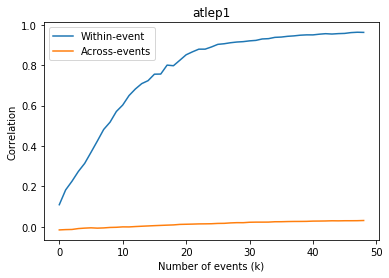

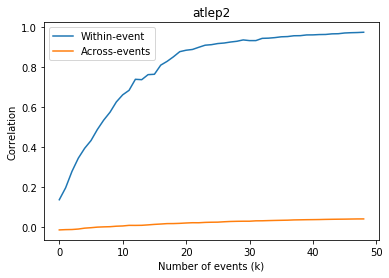

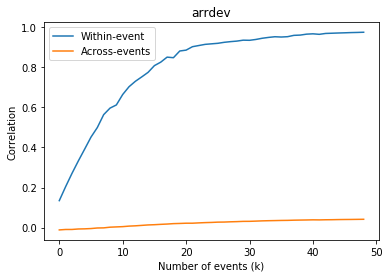

In [7]:
for ep, ks in ep_ks.items():
    plt.plot(list(map(lambda x: x[0], ks)), label='Within-event')
    plt.plot(list(map(lambda x: x[1], ks)), label='Across-events')
    plt.title(ep)
    plt.legend()
    plt.xlabel('Number of events (k)')
    plt.ylabel('Correlation')
    plt.show()

## plot ratio of within- & across-event correlations as a function of k

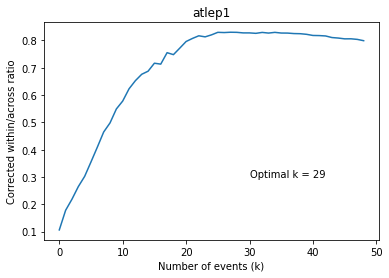

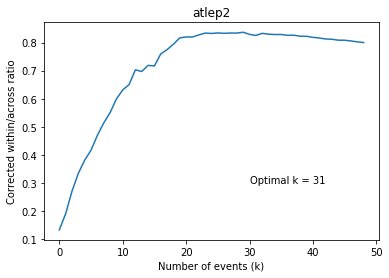

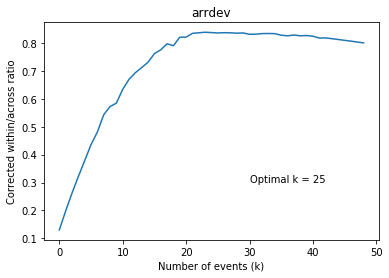

In [44]:
ep_max_ks = []
for ep, ks in ep_ks.items():
    t = list(map(lambda x: x[0]/(x[1]+100), ks))
    t /= np.max(t)
    
    for i, v in enumerate(t):
        t[i] -= (i+2)/250    # regularization term (5 x episode_wsize)
    
    plt.plot(t)
    plt.title(ep)
    plt.ylabel('Corrected within/across ratio')
    plt.xlabel('Number of events (k)')
    maxk = np.argmax(t) + 2
    ep_max_ks.append((ep, maxk))
    
    plt.text(30, .3, f'Optimal k = {maxk}')
    plt.show()

## segment each episode using optimal k; save episode events, eventseg model, onset/offsets

In [207]:
for ep_name, max_k in ep_max_ks:
    ev = event.EventSegment(max_k)
    ev.fit(episode_trajs[ep_name])
    ep_events = reduce_model(episode_trajs[ep_name], ev)
    
    event_times = []
    for s in ev.segments_[0].T:
        tp = np.where(np.round(s)==1)[0]
        event_times.append((tp[0], tp[-1]))
    
    np.save(f'{ep_events_dir}/{ep_name}_events.npy', ep_events)
    np.save(f'{ep_eventtimes_dir}/{ep_name}_event_times.npy', np.array(event_times))
    with open(f'{ep_eventseg_dir}/{ep_name}_eventseg_model.p', 'wb') as f:
        pickle.dump(ev, f)

## NOTE: recall segmentation performed using scripts in `code/cluster-scripts`

## map recall events to episode events, create average recall event models

In [317]:
# load episode event models
episode_events = {ep: np.load(f'{ep_events_dir}/{ep}_events.npy') for ep in ['atlep1', 'atlep2', 'arrdev']}

# load recall event mdoels
recall_events = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed' : [], 'prediction' : []}
for root, dirs, files in os.walk(rec_events_dir):
    indv_events = [f for f in files if f.startswith('debug')]
    if indv_events:
        rectype = os.path.split(root)[1]
        for ev_mod in indv_events:
            recall_events[rectype].append((ev_mod.replace('.npy', ''), np.load(os.path.join(root,ev_mod))))

In [318]:
for rectype, data in recall_events.items():
    
    # set correct reference episode event model
    if rectype == 'delayed':
        ep_events = episode_events['atlep1']
    elif rectype == 'prediction':
        ep_events = episode_events['atlep2']
    else:
        ep_events = episode_events[rectype]
    
    # match recall events to episode events
    matches = np.array([np.argmax(1 - cdist(ep_events, rec_events, 'correlation'), axis=0) 
                        for (turkid, rec_events) in data])
    
    event_mappings = []
    avg = [[] for i in ep_events]
    for match, (turkid, r_ev) in zip(matches, data):
        event_mappings.append((turkid, match))
        for i, m in enumerate(match):
            avg[m].append(r_ev[i,:])
                        
    # average recall for each episode event (fill with 0s if no participant recalled that event)
    avg_p_events = np.array(list(map(lambda r: np.mean(r,0) if len(r)>0 else np.zeros((100,)), avg)))

    # save average events & event mappings
    np.save(os.path.join(rec_events_dir, rectype, 'avg_events.npy'), avg_p_events)
    np.save(os.path.join(rec_events_dir, rectype, 'event_mappings.npy'), np.array(event_mappings))